In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_innovation_kinematics(df, cpc_code):
    """
    Generates a unified 2-panel figure for Patent Innovation Kinematics:
    1. State Space: Position (Count) vs. Velocity (Growth)
    2. Phase Space: Velocity (Growth) vs. Acceleration (Hype/Change)
    """
    # ---------------------------------------------------------
    # 1. DATA PREPARATION (PHYSICS ENGINE)
    # ---------------------------------------------------------
    # Filter and setup time series
    df_cpc = df[df['cpc_group'] == cpc_code].copy()
    df_cpc = df_cpc.set_index('innovation_year').sort_index()
    
    # Ensure continuous timeline (fill missing years with 0)
    # This prevents derivative errors if a year has 0 patents
    if df_cpc.empty:
        print(f"No data for {cpc_code}")
        return
        
    all_years = range(df_cpc.index.min(), df_cpc.index.max() + 1)
    df_cpc = df_cpc.reindex(all_years, fill_value=0)

    # CALCULATE VECTORS
    # Position (x): Smoothed Annual Count
    # We use a 3-year rolling mean to dampen administrative noise
    position = df_cpc['family_count'].rolling(window=3, center=True).mean()
    
    # Velocity (v = dx/dt): Rate of Innovation (New Families/Year)
    velocity = position.diff()
    
    # Acceleration (a = dv/dt): The "Hype" (Change in Rate)
    acceleration = velocity.diff()

    # Clean DataFrame for plotting
    data = pd.DataFrame({
        'Year': position.index,
        'Position': position,
        'Velocity': velocity,
        'Acceleration': acceleration
    }).dropna()

    # ---------------------------------------------------------
    # 2. VISUALIZATION SETUP
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    sns.set_style("whitegrid")
    
    # Helper function to draw the trace with arrows and color-time
    def draw_trace(ax, x_col, y_col, xlabel, ylabel, title, quad_labels):
        # Scatter Points (Color = Time)
        points = ax.scatter(
            data[x_col], data[y_col], 
            c=data['Year'], cmap='viridis', 
            s=120, edgecolor='k', alpha=0.9, zorder=3
        )
        
        # Line Trace (The Path)
        ax.plot(data[x_col], data[y_col], color='gray', alpha=0.4, linewidth=2, zorder=2)
        
        # Directional Arrows (Flow of Time)
        for i in range(len(data) - 1):
            x_start, y_start = data[x_col].iloc[i], data[y_col].iloc[i]
            x_end, y_end = data[x_col].iloc[i+1], data[y_col].iloc[i+1]
            
            # Draw arrow if movement is significant (avoids clutter on small steps)
            if (x_end - x_start)**2 + (y_end - y_start)**2 > 0:
                ax.annotate('', xy=(x_end, y_end), xytext=(x_start, y_start),
                            arrowprops=dict(arrowstyle="->", color='gray', alpha=0.5))

        # Zero Lines (Axes)
        ax.axhline(0, color='black', linestyle='--', alpha=0.5)
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)

        # Labels & Titles
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        
        # Year Annotations (Start/End)
        if not data.empty:
            # Start Year
            ax.text(data[x_col].iloc[0], data[y_col].iloc[0], str(int(data['Year'].iloc[0])), 
                    fontsize=10, fontweight='bold', ha='right')
            # End Year
            ax.text(data[x_col].iloc[-1], data[y_col].iloc[-1], str(int(data['Year'].iloc[-1])), 
                    fontsize=10, fontweight='bold', color='purple', ha='left')
            
        # Quadrant/Region Labels (The "Physics Interpretation")
        xmax, ymax = data[x_col].max(), data[y_col].abs().max()
        if quad_labels:
            ax.text(xmax*0.8, ymax*0.8, quad_labels[0], color='green', fontsize=10, ha='center', 
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
            ax.text(xmax*0.8, -ymax*0.8, quad_labels[1], color='orange', fontsize=10, ha='center', 
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

        return points

    # ---------------------------------------------------------
    # 3. PLOT 1: POSITION vs. VELOCITY (Standard Phase Space)
    # ---------------------------------------------------------
    # Physics: x vs v
    draw_trace(
        axes[0], 'Position', 'Velocity',
        xlabel="Position (Total Annual Filings)",
        ylabel="Velocity (Growth Rate)",
        title=f"A. Growth Trajectory: {cpc_code}\n(Size vs. Speed)",
        quad_labels=("EXPONENTIAL GROWTH\n(Big & Fast)", "MATURATION\n(Big & Slowing)")
    )

    # ---------------------------------------------------------
    # 4. PLOT 2: VELOCITY vs. ACCELERATION (Hype Cycle)
    # ---------------------------------------------------------
    # Physics: v vs a
    points = draw_trace(
        axes[1], 'Velocity', 'Acceleration',
        xlabel="Velocity (Growth Rate)",
        ylabel="Acceleration (Change in Growth)",
        title=f"B. Hype Dynamics: {cpc_code}\n(Speed vs. Force)",
        quad_labels=("BOOM / HYPE\n(Accelerating)", "STAGNATION / COOLING\n(Decelerating)")
    )

    # Colorbar (Shared across both plots)
    cbar = fig.colorbar(points, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
    cbar.set_label('Innovation Year (Light=Old, Dark=New)')

    plt.suptitle(f"Kinematic Analysis of Innovation: {cpc_code}", fontsize=16, y=0.98)
    plt.show()



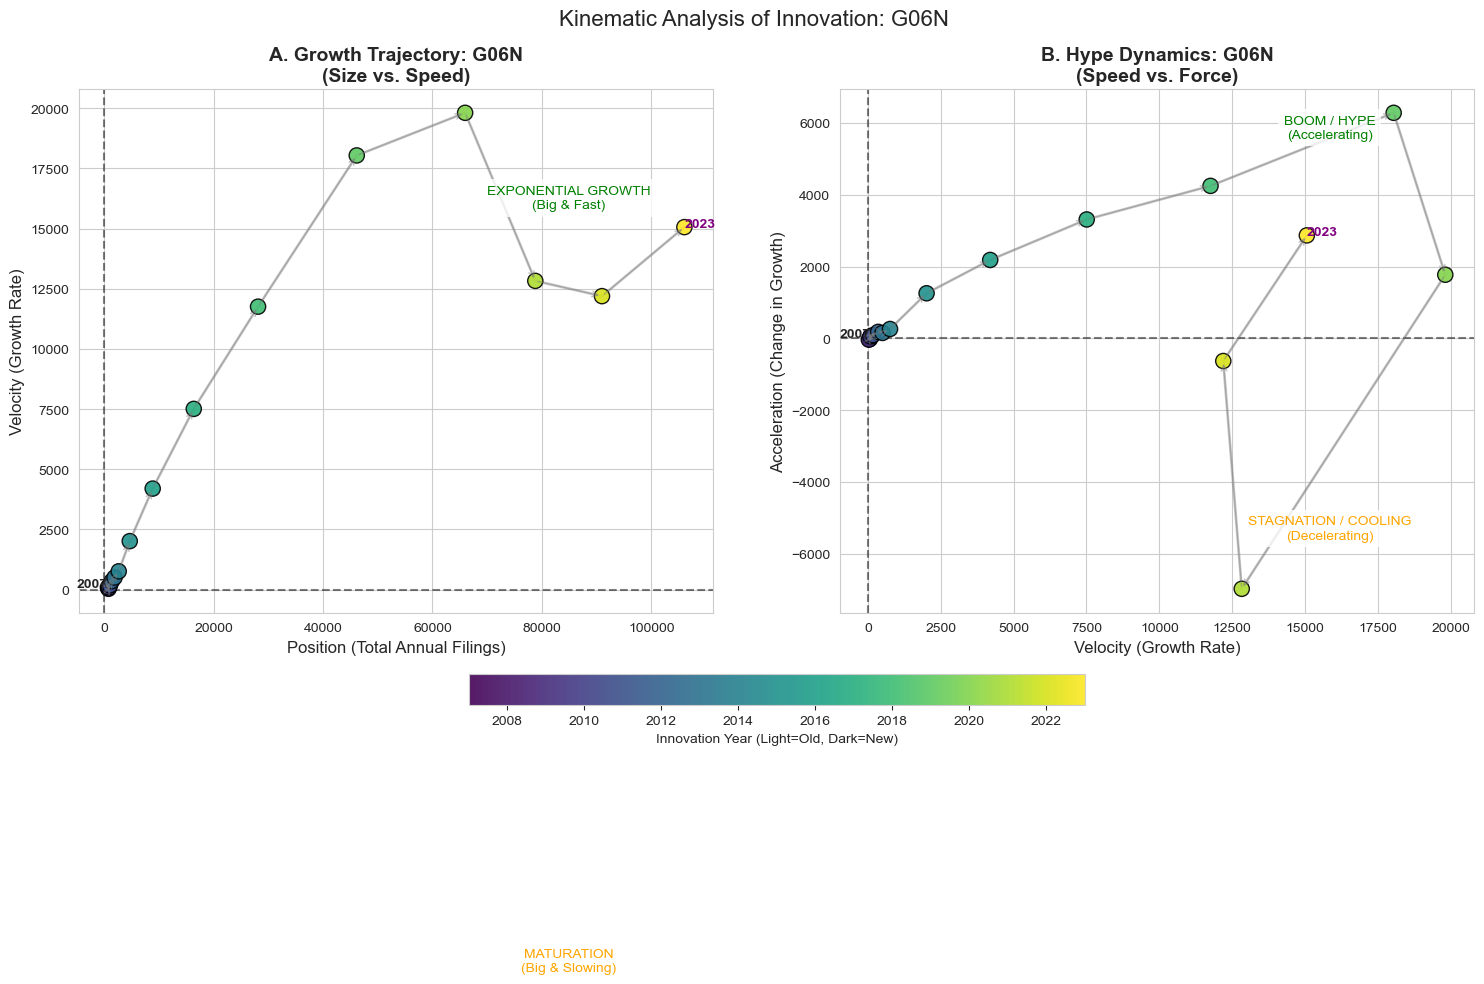

In [17]:
plot_innovation_kinematics(df, 'G06N')

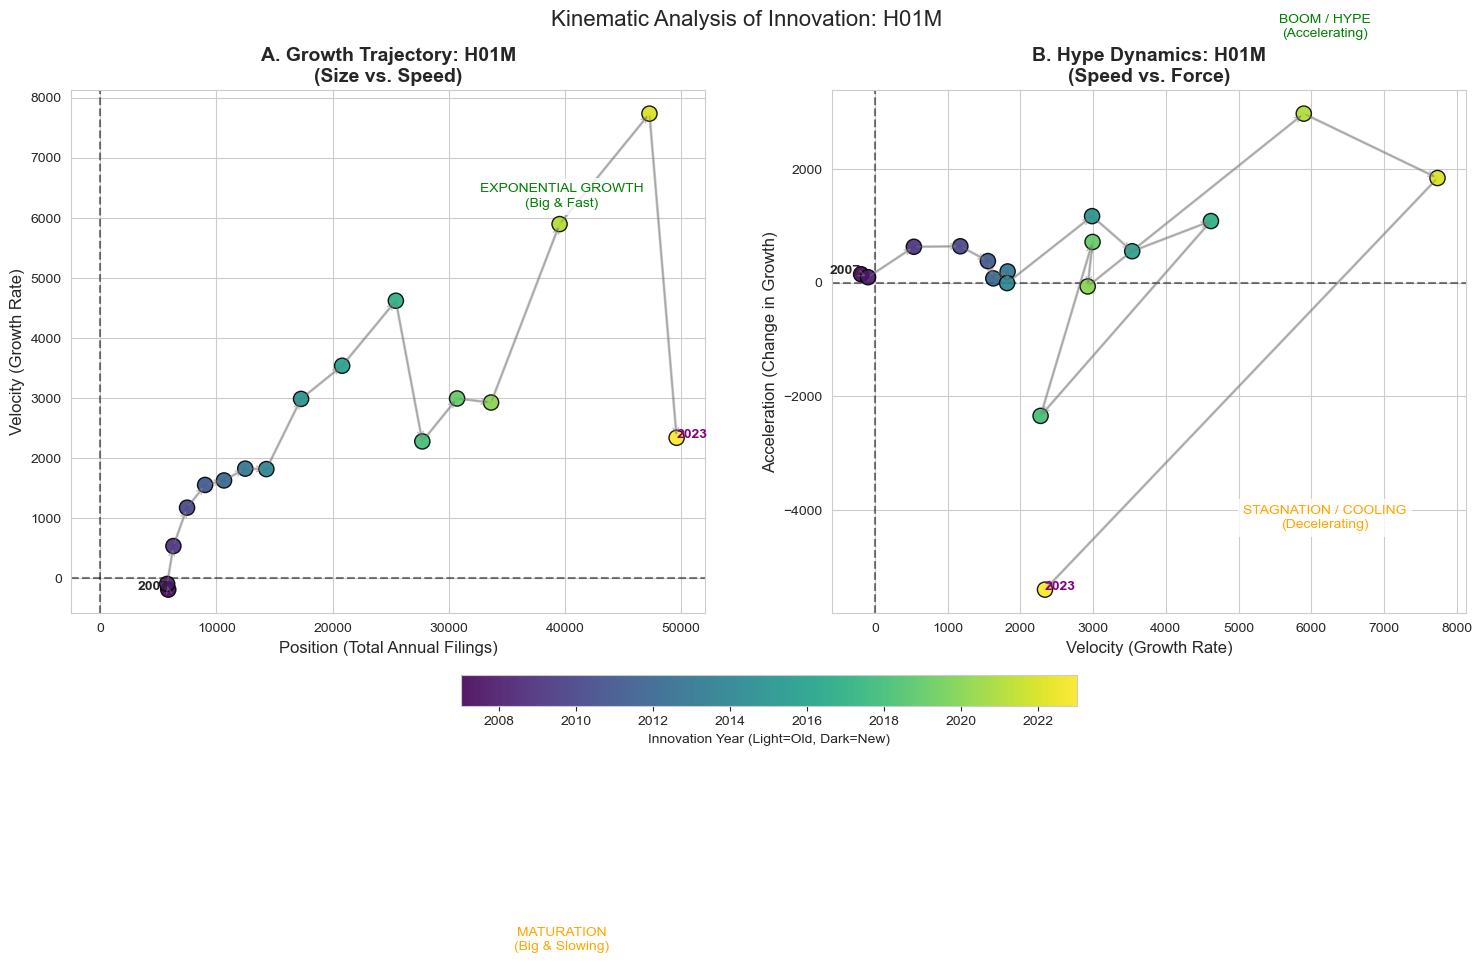

In [18]:
plot_innovation_kinematics(df, 'H01M')

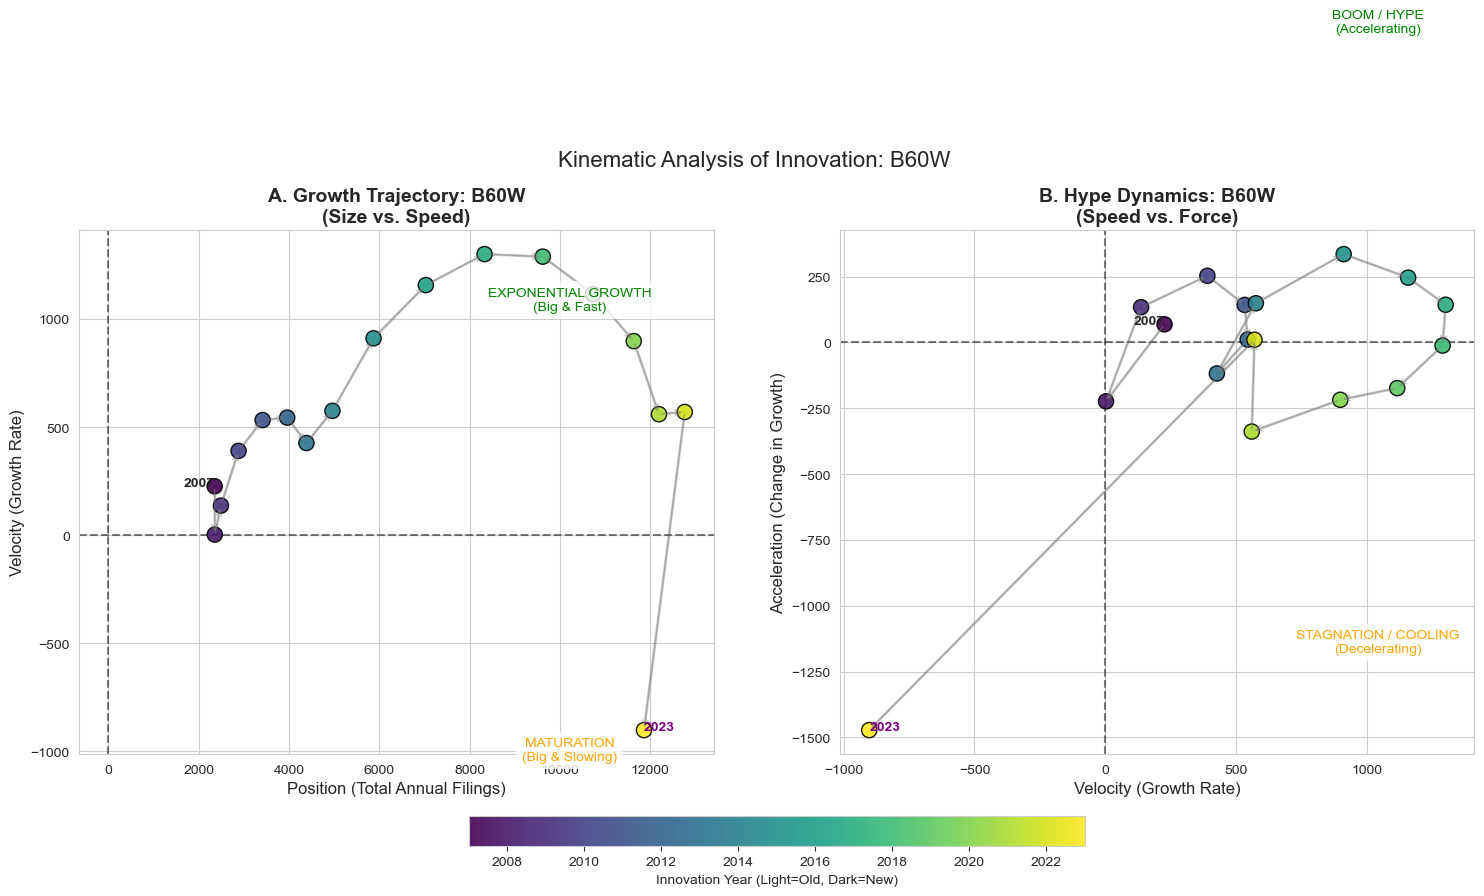

In [19]:
plot_innovation_kinematics(df, 'B60W')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_unified_cumulative_physics(df, cpc_code):
    """
    Generates a unified 2-panel figure for the 'Cumulative Physics Model':
    1. Real Phase Space: Position (Cumulative) vs. Velocity (Annual Count)
    2. Lifecycle Phase Space: Velocity (Annual Count) vs. Acceleration (Growth Trend)
    """
    # ---------------------------------------------------------
    # 1. SETUP DATA
    # ---------------------------------------------------------
    df_cpc = df[df['cpc_group'] == cpc_code].copy()
    df_cpc = df_cpc.set_index('innovation_year').sort_index()
    
    # Fill gaps to ensure continuous timeline
    if df_cpc.empty:
        print(f"No data for {cpc_code}")
        return
    all_years = range(df_cpc.index.min(), df_cpc.index.max() + 1)
    df_cpc = df_cpc.reindex(all_years, fill_value=0)

    # ---------------------------------------------------------
    # 2. CALCULATE VECTORS (Cumulative Model)
    # ---------------------------------------------------------
    # v (Velocity) = Annual Count (Smoothed)
    # Represents the "Speed" of innovation (dx/dt)
    velocity = df_cpc['family_count'].rolling(window=3, center=True).mean()
    
    # x (Position) = Cumulative Total of the Velocity
    # Represents "Total Accumulated Knowledge" (Integral of v)
    position = velocity.cumsum()
    
    # a (Acceleration) = Change in Velocity
    # Represents "Force" (Market Pull or Saturation Drag)
    acceleration = velocity.diff()

    # Clean Data
    data = pd.DataFrame({
        'Year': velocity.index,
        'Position': position,       # Cumulative (x)
        'Velocity': velocity,       # Annual (v)
        'Acceleration': acceleration # Trend (a)
    }).dropna()

    # ---------------------------------------------------------
    # 3. VISUALIZATION SETUP
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    sns.set_style("whitegrid")
    
    # Helper for consistent plotting
    def draw_phase_plot(ax, x_col, y_col, xlabel, ylabel, title, quad_labels=None):
        # Scatter (Color = Time)
        points = ax.scatter(
            data[x_col], data[y_col], 
            c=data['Year'], cmap='plasma', 
            s=120, edgecolor='k', alpha=0.9, zorder=3
        )
        
        # Trace
        ax.plot(data[x_col], data[y_col], color='gray', alpha=0.4, linewidth=2, zorder=2)
        
        # Arrows (Flow of Time)
        for i in range(len(data) - 1):
            x0, y0 = data[x_col].iloc[i], data[y_col].iloc[i]
            x1, y1 = data[x_col].iloc[i+1], data[y_col].iloc[i+1]
            if (x1-x0)**2 + (y1-y0)**2 > 0:
                ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                            arrowprops=dict(arrowstyle="->", color='gray', alpha=0.4))

        # Annotations
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.axhline(0, color='black', linestyle='--', alpha=0.5)
        
        # Start/End Labels
        if not data.empty:
            ax.text(data[x_col].iloc[0], data[y_col].iloc[0], str(int(data['Year'].iloc[0])), 
                    fontsize=10, fontweight='bold', ha='right')
            ax.text(data[x_col].iloc[-1], data[y_col].iloc[-1], str(int(data['Year'].iloc[-1])), 
                    fontsize=10, fontweight='bold', color='purple', ha='left')

        # Custom Labels (Quadrants/Regions)
        if quad_labels:
            x_pos = data[x_col].max() * 0.5
            y_max = data[y_col].abs().max()
            ax.text(x_pos, y_max * 0.8, quad_labels[0], color='green', ha='center',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
            ax.text(x_pos, -y_max * 0.8, quad_labels[1], color='red', ha='center',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

        return points

    # ---------------------------------------------------------
    # PLOT A: REAL PHASE SPACE (x vs v)
    # Interpretation: "The Arch" - How fast are we going given our size?
    # ---------------------------------------------------------
    draw_phase_plot(
        axes[0], 'Position', 'Velocity',
        xlabel="Position: Cumulative Patent Families (Total Size)",
        ylabel="Velocity: Annual Filing Count (Speed)",
        title=f"A. Real Phase Space: {cpc_code}\n(Position vs. Velocity)",
        quad_labels=None 
    )
    # Add context text for the S-Curve derivative shape
    axes[0].text(0.05, 0.9, "Early Growth", transform=axes[0].transAxes, color='gray', fontsize=10)
    axes[0].text(0.8, 0.2, "Saturation?", transform=axes[0].transAxes, color='gray', fontsize=10)

    # ---------------------------------------------------------
    # PLOT B: LIFECYCLE PHASE SPACE (v vs a)
    # Interpretation: "The Loop" - Is the speed increasing or decreasing?
    # ---------------------------------------------------------
    points = draw_phase_plot(
        axes[1], 'Velocity', 'Acceleration',
        xlabel="Velocity: Annual Filing Count (Speed)",
        ylabel="Acceleration: YoY Growth (Force)",
        title=f"B. Lifecycle Phase Space: {cpc_code}\n(Velocity vs. Acceleration)",
        quad_labels=("ACCELERATION (Boom)", "DECELERATION (Cooling)")
    )
    # Vertical line for Acceleration=0 (since Velocity is always >0 here)
    axes[1].axvline(0, color='black', linestyle='--', alpha=0.1)

    # Colorbar
    cbar = fig.colorbar(points, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
    cbar.set_label('Innovation Year (Light=Old, Dark=New)')

    plt.suptitle(f"Unified Innovation Physics: {cpc_code} (Cumulative Model)", fontsize=16, y=0.98)
    plt.show()



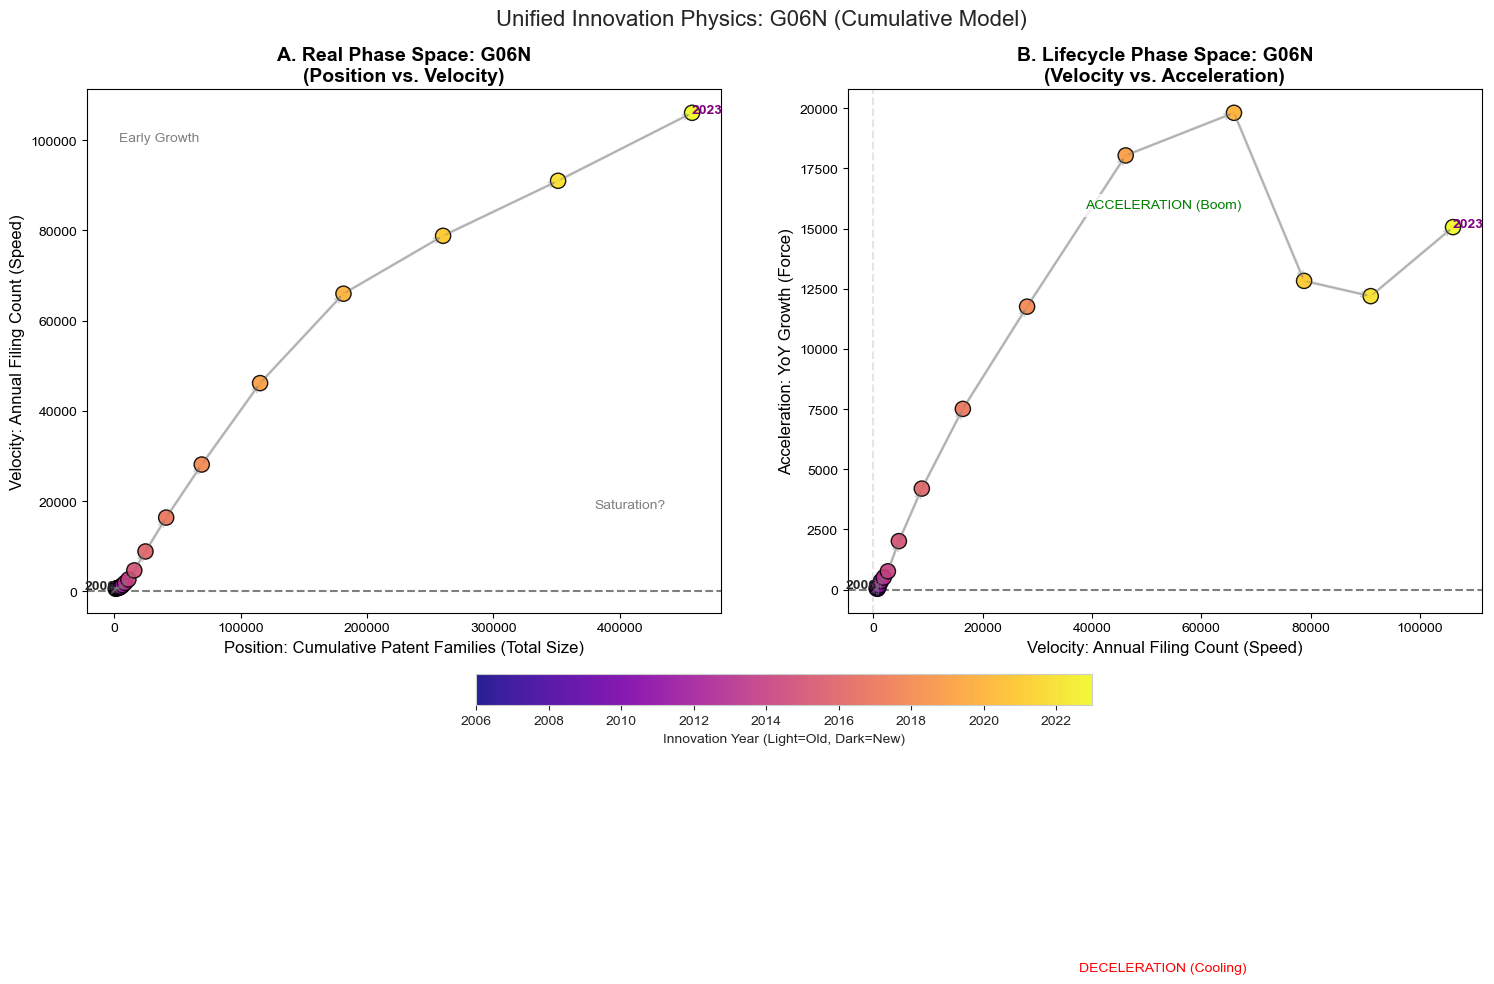

In [5]:
df = pd.read_csv("innovation_velocity_2003-2024_calibration.csv")
plot_unified_cumulative_physics(df, 'G06N')

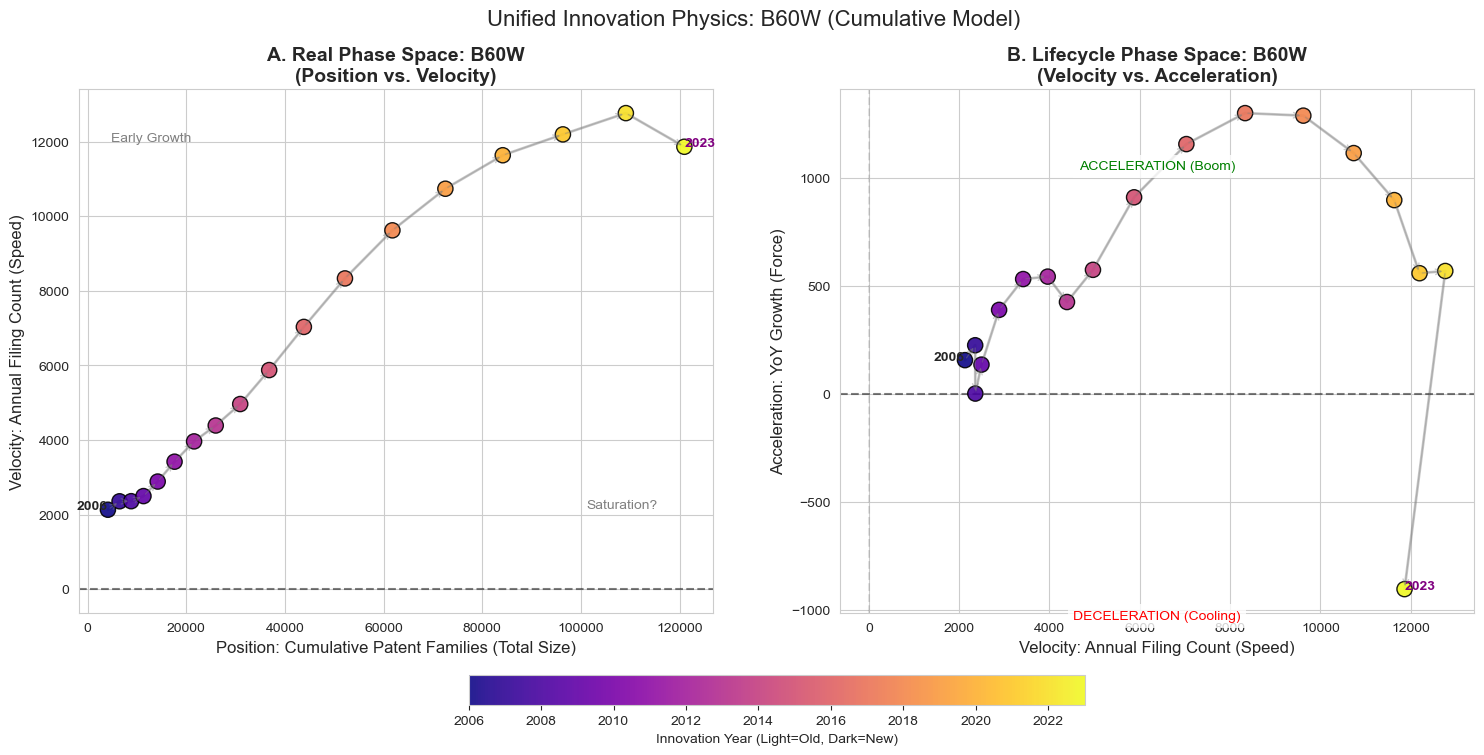

In [6]:
plot_unified_cumulative_physics(df, 'B60W')

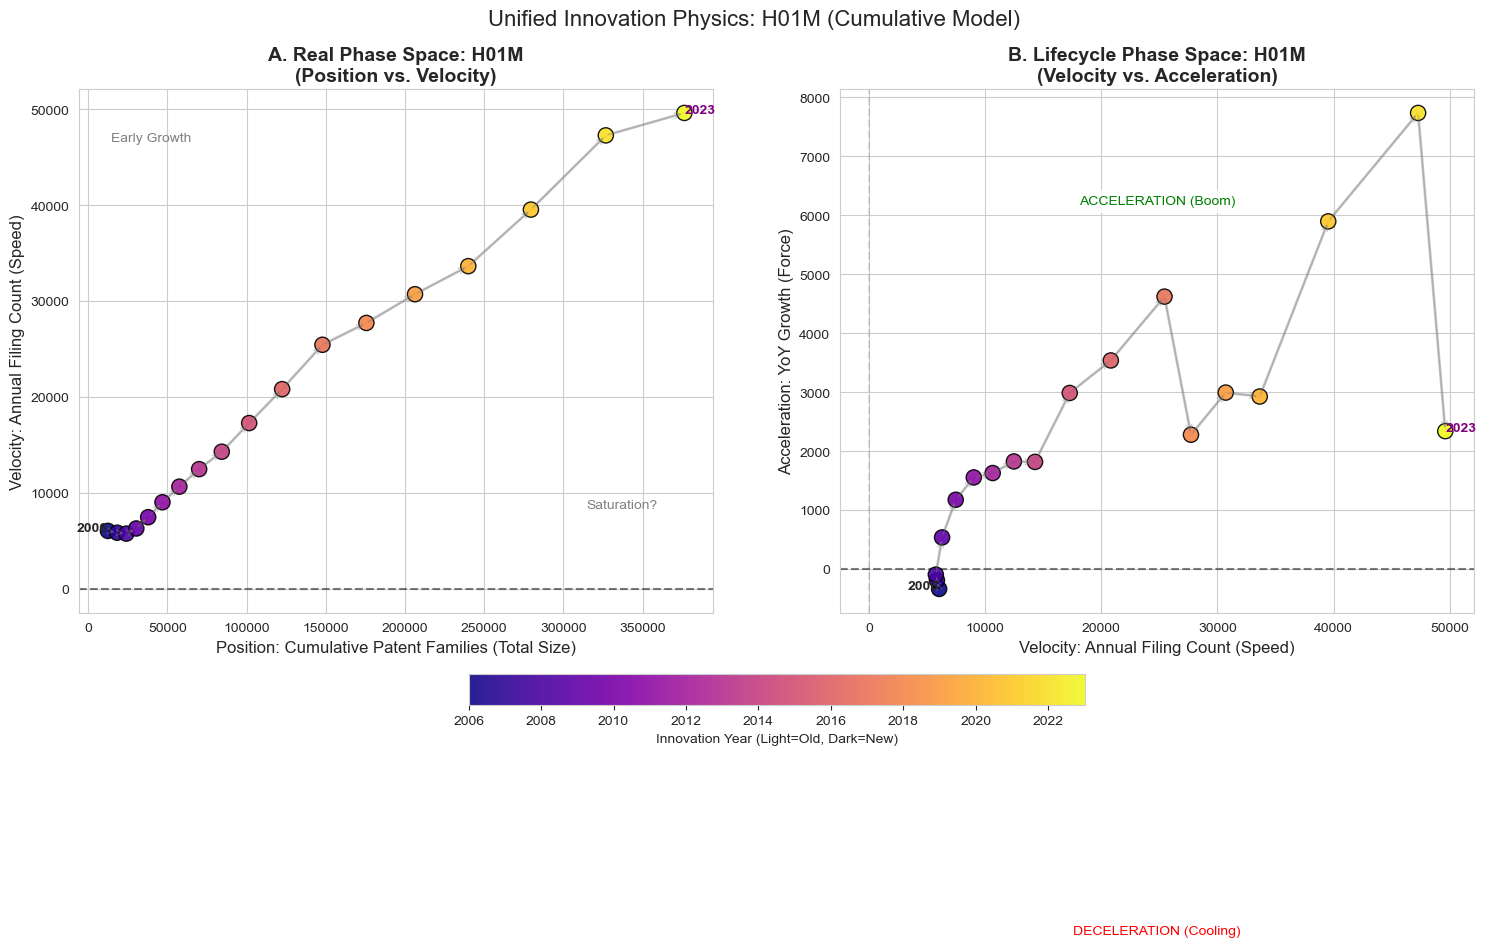

In [8]:
plot_unified_cumulative_physics(df, 'H01M')

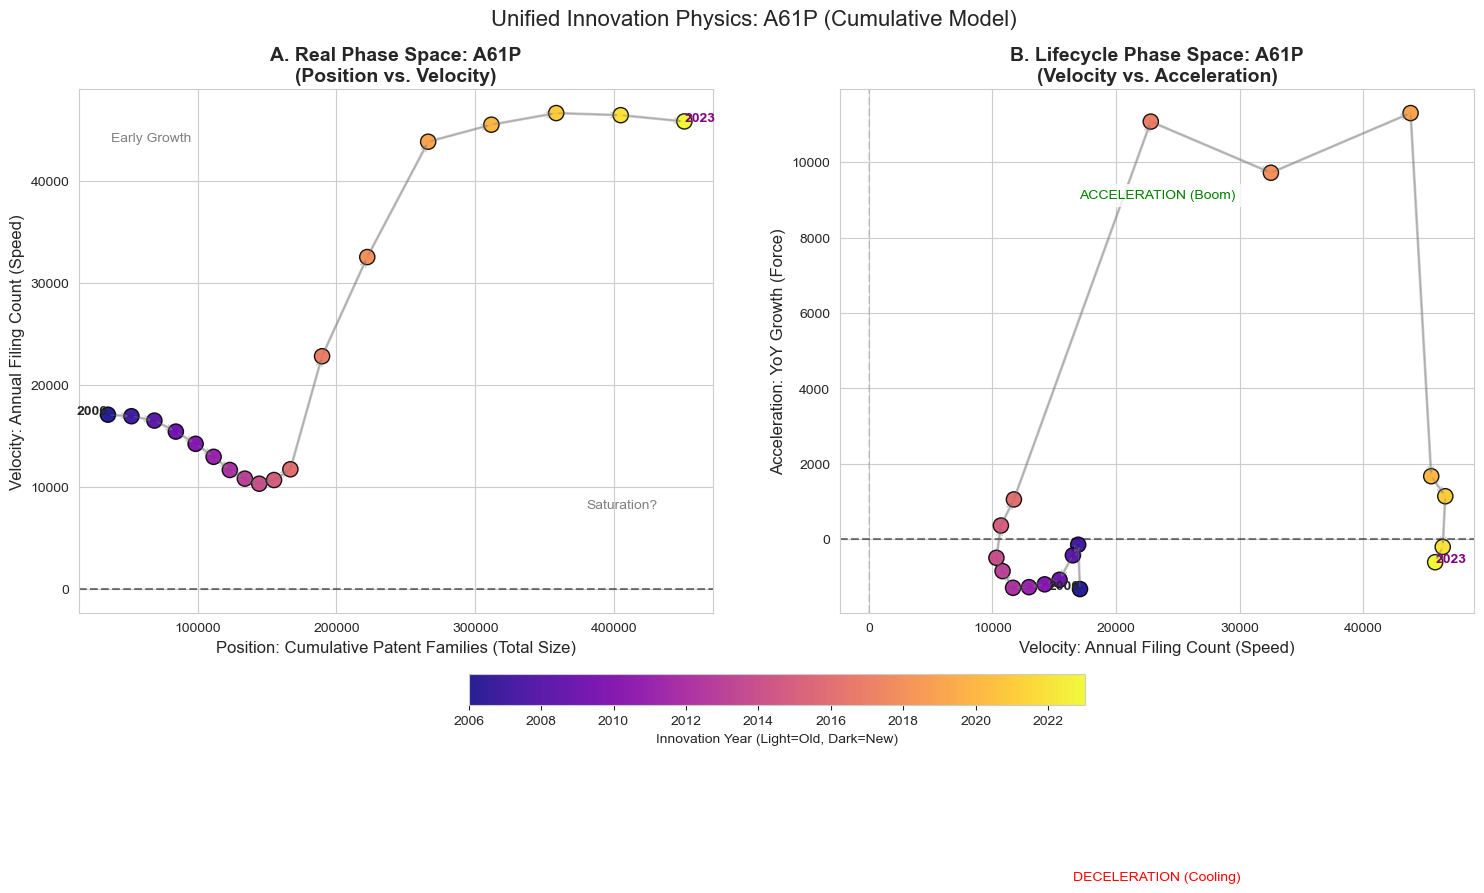

In [9]:
plot_unified_cumulative_physics(df, 'A61P')